# Project 2: Exploratory Data Analysis (EDA)

## Objective
The objective of this project was to perform Exploratory Data Analysis (EDA) on a cleaned e-commerce dataset to identify patterns, trends, outliers, and actionable business insights.

## Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [3]:
df = pd.read_excel('cleaned_dataset.xlsx')
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Dataset Overview

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

## Descriptive Statistics

In [ ]:
df['TotalPrice'].describe()

,TotalPrice
count,1200.000000
mean,1053.968300
std,819.856558
min,11.390000
25%,410.520000
50%,823.615000
75%,1578.475000
max,3456.400000


## Outliers Analysis

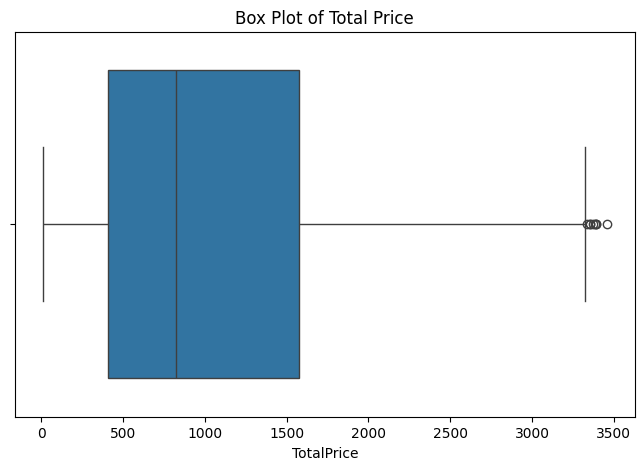

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['TotalPrice'])
plt.title('Box Plot of Total Price')
plt.show()

###Observation:
The box plot identified that most orders fall within a lower price range, while a small number of high-value orders appear as outliers.

In [ ]:
df.nlargest(20,'TotalPrice')[['Product', 'UnitPrice', 'TotalPrice']]

,Product,UnitPrice,TotalPrice
789,Tablet,691.28,3456.40
1122,Monitor,678.19,3390.95
632,Laptop,678.16,3390.80
469,Chair,676.98,3384.90
328,Tablet,674.04,3370.20
107,Printer,670.75,3353.75
326,Laptop,670.48,3352.40
1065,Printer,666.80,3334.00
1031,Phone,664.51,3322.55
463,Laptop,662.78,3313.90


### Observation:
Further investigation of the largest transactions showed that these orders were associated with legitimate high-priced products such as tablets, laptops, monitors, and printers. Therefore, the outliers were retained as valid business transactions rather than removed.

## Distribution Analysis

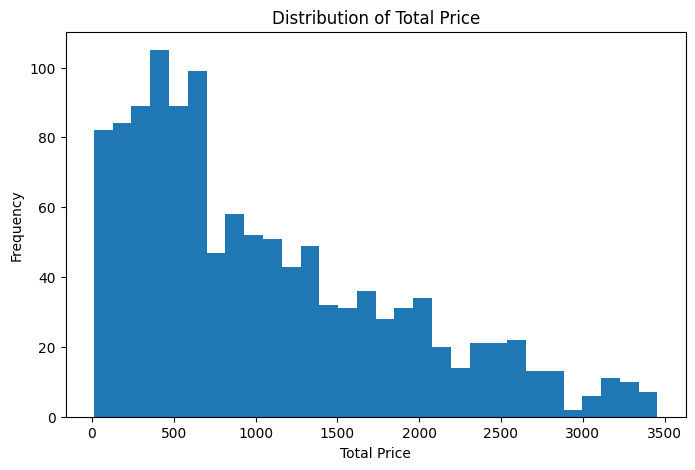

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['TotalPrice'],bins=30)
plt.title('Distribution of Total Price')
plt.xlabel('Total Price')
plt.ylabel('Frequency')
plt.show()

###Observation:
The distribution of TotalPrice is positively (right) skewed. Most orders are concentrated in the lower price range, indicating that customers typically make smaller purchases. This aligns with the outliers identified in the box plot and suggests that these high-value orders are uncommon but valid business transactions.

## Product Analysis

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


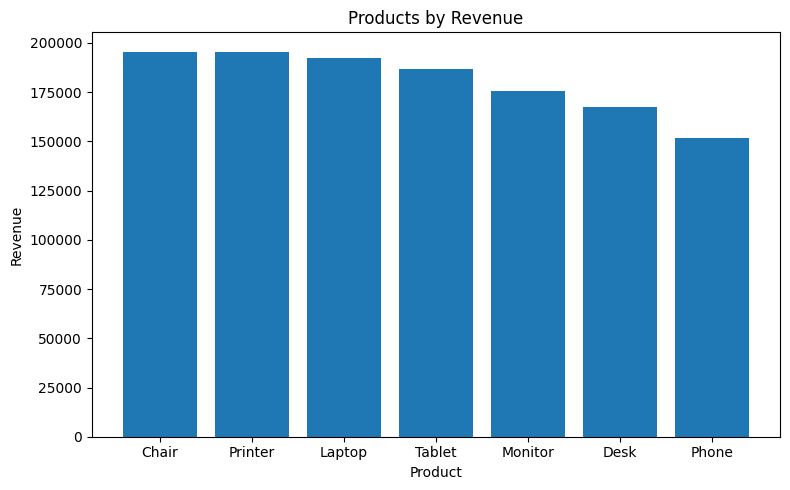

In [ ]:
# Top Products by Revenue

top_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
print(top_revenue)

plt.figure(figsize=(8,5))
plt.bar(top_revenue.index, top_revenue)
plt.title('Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

### Observation:
Chairs generated the highest revenue (195,620.11), narrowly outperforming Printers (195,612.61) and Laptops (192,126.56). Phones generated the lowest revenue (151,722.39). This suggests that Chairs, Printers and Laptops are the top revenue generating products.

Product
Chair      562
Printer    542
Laptop     535
Desk       508
Tablet     497
Monitor    480
Phone      411
Name: Quantity, dtype: int64


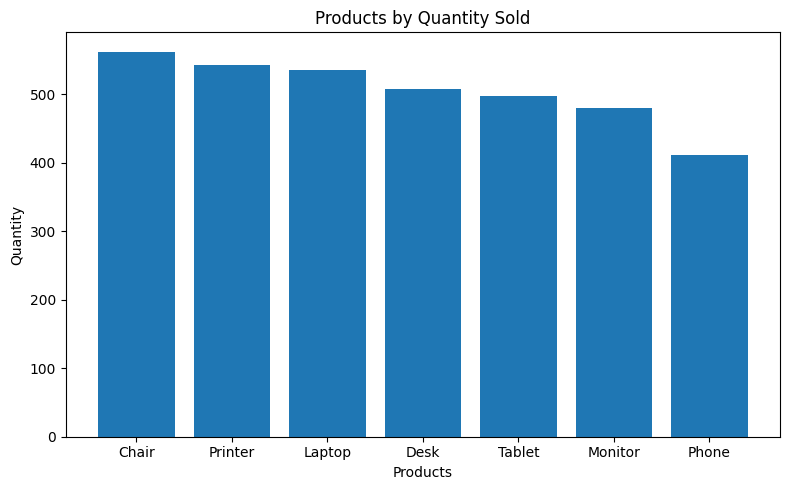

In [ ]:
# Top Products by Quantity Sold

most_sold = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
print(most_sold)

plt.figure(figsize=(8,5))
plt.bar(most_sold.index, most_sold)
plt.title('Products by Quantity Sold')
plt.xlabel('Products')
plt.ylabel('Quantity')
plt.tight_layout()
plt.show()

###Observation:
 Chairs generated the highest revenue (195,620.11), narrowly outperforming Printers (195,612.61) and Laptops (192,126.56). Phones generated the lowest revenue (151,722.39). The similarity between the revenue ranking and sales volume ranking indicates that revenue performance was largely driven by the number of units sold rather than significant price differences between products.

## Payment Method Analysis

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


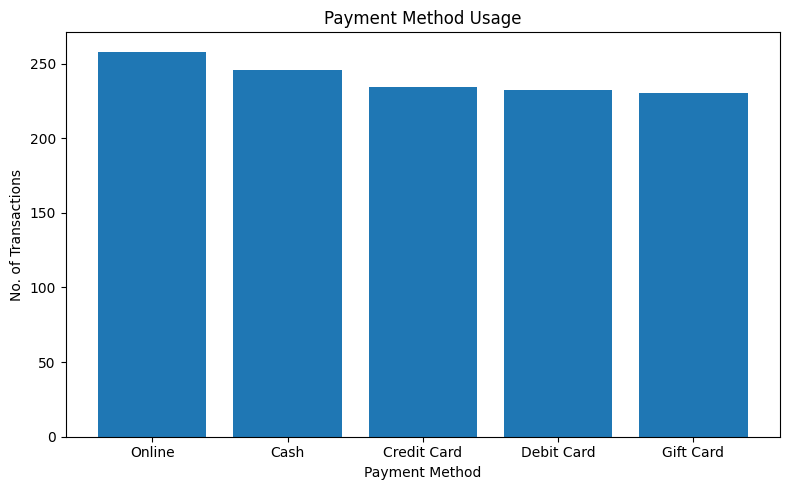

In [ ]:
# Most used payment method

payment_count = df['PaymentMethod'].value_counts()
print(payment_count)

plt.figure(figsize=(8,5))
plt.bar(payment_count.index, payment_count)
plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('No. of Transactions')
plt.tight_layout()
plt.show()

###Observation:
 Online payments were the most frequently used payment method, accounting for 258 transactions. Cash followed closely with 246 transactions, while Gift Cards were the least frequently used payment method with 230 transactions. The relatively small differences between payment methods suggest customers are fairly distributed across payment options.

PaymentMethod
Credit Card    263847.63
Online         262442.94
Cash           259786.29
Gift Card      246323.92
Debit Card     232361.18
Name: TotalPrice, dtype: float64


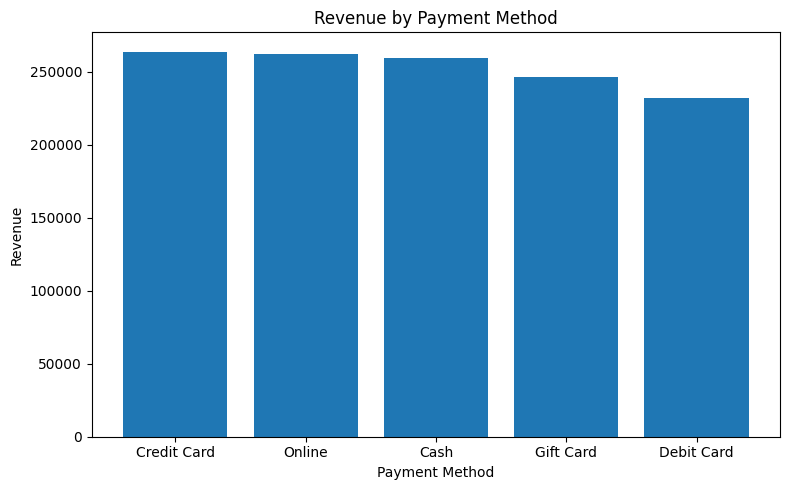

In [ ]:
#Revenue by Payment Method

payment_revenue = df.groupby('PaymentMethod')['TotalPrice'].sum().sort_values(ascending=False)
print(payment_revenue)

plt.figure(figsize=(8,5))
plt.bar(payment_revenue.index, payment_revenue)
plt.title('Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

###Observation:
Although Online payments recorded the highest number of transactions, Credit Cards generated the highest revenue (263,847.63). This indicates that customers paying with Credit Cards tended to place higher-value orders on average. Debit Cards generated the lowest revenue (232,361.18), suggesting lower average spending among users of that payment method.

## Referral Source Analysis

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


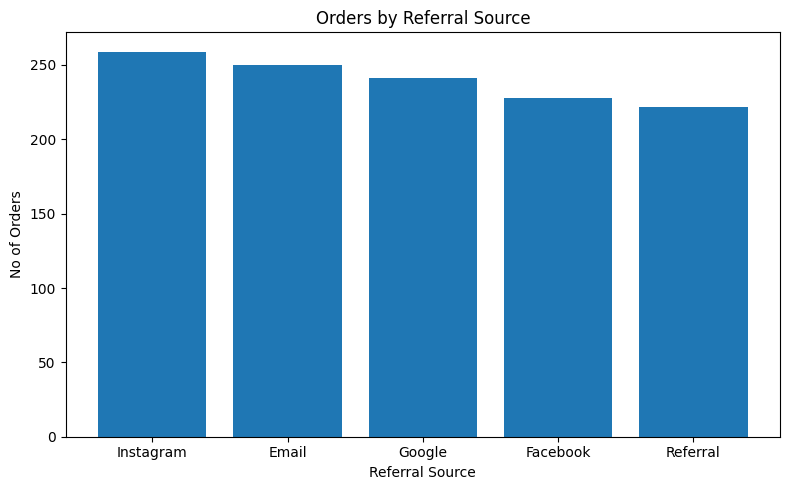

In [ ]:
#Orders by referral source

referral_orders = df['ReferralSource'].value_counts()
print(referral_orders)

plt.figure(figsize=(8,5))
plt.bar(referral_orders.index,referral_orders)
plt.title('Orders by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('No of Orders')
plt.tight_layout()
plt.show()

###Observation:
Instagram generated the highest number of orders (259), followed by Email (250) and Google (241). Referral generated the fewest orders (222). The differences are relatively small, indicating that customer acquisition is spread fairly evenly across marketing channels.

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64


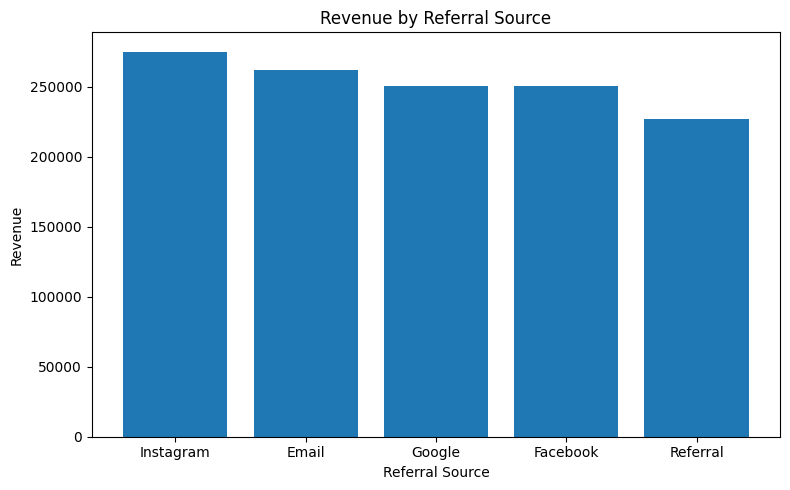

In [ ]:
#Revenue by referral source

referral_revenue = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)
print(referral_revenue)

plt.figure(figsize=(8,5))
plt.bar(referral_revenue.index,referral_revenue)
plt.title('Revenue by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

###Observation:
Instagram also generated the highest revenue (275,285.45), followed by Email (261,808.55). Referral generated the lowest revenue (226,815.58). This suggests that Instagram was the most effective channel in both attracting customers and driving sales revenue.

## Order Status Analysis

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


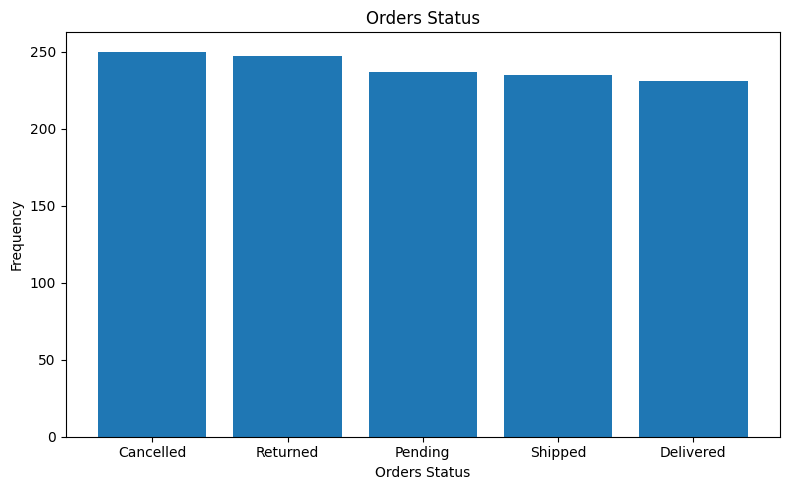

In [ ]:

#Orders status
order_status = df['OrderStatus'].value_counts()
print(order_status)

plt.figure(figsize=(8,5))
plt.bar(order_status.index, order_status)
plt.title('Orders Status')
plt.xlabel('Orders Status')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

###Observation:
Order counts were fairly evenly distributed across all order statuses. Cancelled orders recorded the highest count (250), followed closely by Returned (247), Pending (237), Shipped (235), and Delivered (231). The small differences suggest that no single order status dominated the dataset.

OrderStatus
Cancelled    276396.21
Pending      256328.15
Shipped      246159.58
Returned     243277.70
Delivered    242600.32
Name: TotalPrice, dtype: float64


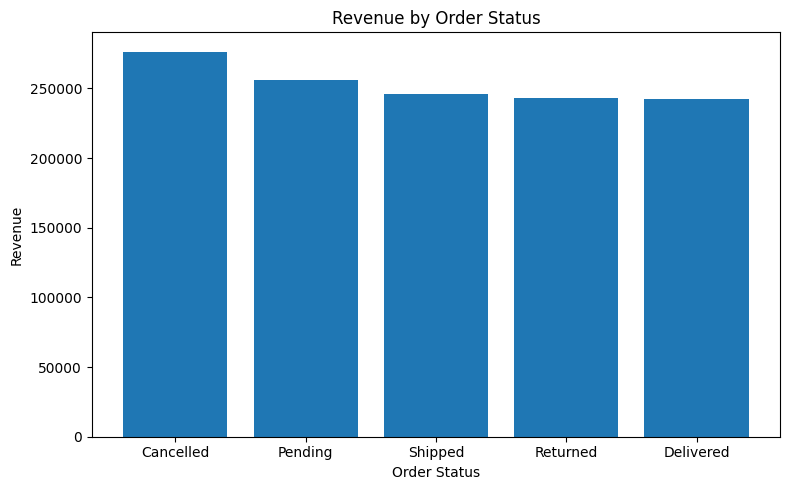

In [ ]:
#Revenue by Order Status

order_revenue = df.groupby('OrderStatus')['TotalPrice'].sum().sort_values(ascending=False)
print(order_revenue)

plt.figure(figsize=(8,5))
plt.bar(order_revenue.index, order_revenue)
plt.title('Revenue by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

###Observation:
Cancelled orders generated the highest revenue (276,396.21), while Delivered orders generated the lowest revenue (242,600.32). Revenue distribution across statuses was relatively balanced, with no category accounting for a disproportionately large share of sales value.

## Monthly Trend Analysis

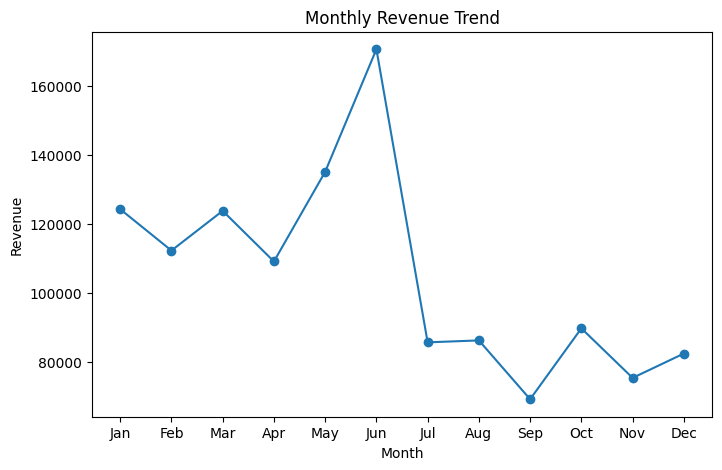

In [ ]:
# Monthly Revenue Trend

import calendar

monthly_revenue = df.groupby(df['Date'].dt.month)['TotalPrice'].sum()

plt.figure(figsize=(8,5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')
plt.xticks(range(1,13), calendar.month_abbr[1:13])
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

###Observation:
Monthly revenue fluctuated throughout the year. Revenue increased steadily from April to June, reaching its peak in June at approximately 170,000. Following June, revenue experienced a sharp decline in July and remained relatively lower for the rest of the year. September recorded the lowest revenue, while a modest recovery was observed in October and December.

## Correlation Heatmap

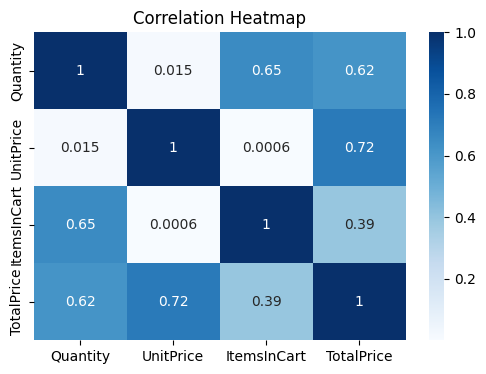

In [ ]:

corr = df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

###Observation:
Quantity and ItemsInCart (0.65): moderately strong positive. Carts with more items tend to have higher quantities.

Quantity and TotalPrice (0.62) : moderately strong. More quantity, more total spend.

UnitPrice and TotalPrice (0.72) : the strongest relationship here. Unit price is a bigger driver of total price than quantity is.

UnitPrice and Quantity (0.015) : no relationship. People don't buy more units because the price is higher or lower.

UnitPrice and ItemsInCart (0.0006): basically zero. Cart size doesn't relate to individual item price at all.

ItemsInCart and TotalPrice (0.39): weak-to-moderate. More items in cart nudges total price up, but not as strongly as unit price or quantity do.

## Key Insights:
1. **Chairs Are the Best-Performing Product:**
Chairs recorded both the highest sales volume and the highest total revenue, making them the strongest-performing product category in the dataset.
2. **Online Payments Are Most Popular, but Credit Cards Generate More Revenue:**
Online payment was the most frequently used payment method. However, Credit Card transactions generated the highest revenue, suggesting that customers using credit cards tend to make larger purchases.
3. **Instagram Is the Most Effective Acquisition Channel:**
Instagram produced both the highest number of orders and the highest revenue, making it the strongest referral source in the dataset.
4. **Order Cancellations Represent a Significant Revenue Risk:**
Cancelled orders had the highest count and revenue value among all order statuses. This indicates a potential loss of revenue and highlights the need to investigate why customers are cancelling orders.
5. **Revenue Peaks Mid-Year:**
Monthly revenue reached its highest level in June before declining sharply in the second half of the year. This pattern may suggest seasonal demand or changes in customer purchasing behavior.

##Recommendations:
**1. Grow Instagram Investment:**
Instagram generates both the highest order volume and the highest revenue among all referral channels. The business should increase investment in this channel while continuing to leverage the strategies driving its success. Lower-performing channels, such as Referral and Facebook, should be reviewed, with consideration given to reallocating part of their marketing budget toward higher-performing channels.

**2. Investigate and Reduce Order Cancellations:**
Cancelled orders account for the highest order count and revenue value, representing a significant risk to overall revenue. A root-cause analysis should be conducted to identify the factors driving cancellations, followed by targeted interventions to reduce cancellation rates and improve revenue retention.

**3. Prioritize Top-Performing Products and Encourage Bundling:**
Chairs, Printers, and Laptops are the strongest contributors to both sales volume and revenue. These products should be prioritized in inventory planning, promotional campaigns, and product placement strategies. Additionally, given the positive relationship between ItemsInCart and TotalPrice, product bundling and cross-selling initiatives may help increase average order value.

**4. Manage Seasonal Revenue Fluctuations:**
Revenue peaked in June before declining significantly during the second half of the year. The business should identify the factors that contributed to June's strong performance and replicate successful strategies where feasible. Promotional campaigns, loyalty programs, and targeted marketing efforts during lower-performing periods may help stabilize revenue throughout the year.

**5. Encourage Credit Card Usage:**
Although Online payments are the most frequently used payment method, Credit Card transactions generate the highest revenue. Offering incentives such as discounts, cashback rewards, or loyalty points for credit card payments may encourage higher-value purchases and increase overall revenue.